# Courville et al. second-order conditioning sweep

This notebook contains a reimplementation of the following paper: A. C. Courville, G. J. Gordon, D. Touretzky, and N. Daw. Model
Uncertainty in Classical Conditioning. In Advances in Neural
Information Processing Systems, volume 16. MIT Press, 2003.


In [1]:
from pathlib import Path
import csv
import json
import sys

cwd = Path.cwd().resolve()
repo_root = None
for candidate in (cwd, *cwd.parents):
    if (candidate / "reimplement" / "models.py").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing reimplement/models.py")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from reimplement.data import STIMULUS_NAMES, conditioning_query, generate_second_order_conditioning
from reimplement.models import ParallelTemperingRJMCMC, RJMCMCSigmoidBeliefNetwork, sample_summary

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

OUTPUT_DATA_DIR = Path("outputs") / "latent_data"
OUTPUT_IMAGE_DIR = Path("outputs") / "images"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)


## Setup and helpers

Load the reimplementation modules, define the predictive queries, and prepare the helper routines used by the sweep.


In [2]:
QUERY_DEFINITIONS = {
    "P(US|A,D)": ("A",),
    "P(US|X,D)": ("X",),
    "P(US|B,D)": ("B",),
    "P(US|X,B,D)": ("X", "B"),
}

def posterior_predictive_queries(sampler, samples):
    us_index = STIMULUS_NAMES.index("US")
    outputs = {}
    for label, present in QUERY_DEFINITIONS.items():
        values, mask = conditioning_query(present, stimulus_names=STIMULUS_NAMES)
        probabilities = sampler.posterior_predictive(values, mask, samples=samples)
        outputs[label] = float(probabilities[us_index])
    return outputs

def run_single_conditioning_chain(
    ax_trials,
    iterations,
    burn_in,
    thin,
    seed,
    init_causes=2,
    use_parallel_tempering=True,
    verbose_every=0,
):
    print(f"Starting fit for ax={ax_trials}, seed={seed}, tempered={use_parallel_tempering}")
    observations = generate_second_order_conditioning(ax_trials=ax_trials)
    if use_parallel_tempering:
        sampler = ParallelTemperingRJMCMC(
            observations,
            inverse_temperatures=(1.0, 0.7, 0.45, 0.25),
            init_causes=init_causes,
            init_strategy="empirical_patterns",
            seed=seed,
        )
    else:
        sampler = RJMCMCSigmoidBeliefNetwork(
            observations,
            init_causes=init_causes,
            init_strategy="empirical_patterns",
            seed=seed,
        )
    samples = sampler.run(
        iterations=iterations,
        burn_in=burn_in,
        thin=thin,
        store_latents=True,
        verbose_every=verbose_every,
    )
    if use_parallel_tempering:
        cold_sampler = sampler.cold_sampler
        accept_rate = float(np.mean([entry["accepted"] for entry in cold_sampler.trace])) if cold_sampler.trace else 0.0
        predictive_sampler = cold_sampler
    else:
        accept_rate = float(np.mean([entry["accepted"] for entry in sampler.trace])) if sampler.trace else 0.0
        predictive_sampler = sampler
    predictive = posterior_predictive_queries(predictive_sampler, samples)
    print(
        f"Completed ax={ax_trials}, seed={seed}: "
        f"A={predictive['P(US|A,D)']:.3f} "
        f"X={predictive['P(US|X,D)']:.3f} "
        f"B={predictive['P(US|B,D)']:.3f} "
        f"XB={predictive['P(US|X,B,D)']:.3f} "
        f"accept={accept_rate:.3f}"
    )
    return {
        "ax_trials": int(ax_trials),
        "seed": int(seed),
        "posterior": sample_summary(samples),
        "predictive": predictive,
        "accept_rate": accept_rate,
        "structure": summarize_mode_cause_structure(samples),
    }

def summarize_across_chains(values):
    values = np.asarray(values, dtype=float)
    center = float(np.median(values))
    lower = float(np.quantile(values, 0.25))
    upper = float(np.quantile(values, 0.75))
    mean = float(np.mean(values))
    std = float(np.std(values))
    return {
        'center': center,
        'lower': lower,
        'upper': upper,
        'mean': mean,
        'std': std,
    }

def run_ax_trial_sweep(
    ax_trial_grid,
    chains_per_point,
    iterations,
    burn_in,
    thin,
    base_seed,
    init_causes=2,
    small_ax_chains=None,
    use_parallel_tempering=True,
    verbose_every=0,
):
    ax_trial_grid = np.asarray(ax_trial_grid, dtype=int)
    aggregated = {
        label: {"center": [], "lower": [], "upper": [], "mean": [], "std": []}
        for label in QUERY_DEFINITIONS
    }
    aggregated["mean_num_causes"] = {"center": [], "lower": [], "upper": [], "mean": [], "std": []}
    chain_results = []
    seed_stride = max(chains_per_point, small_ax_chains or chains_per_point)

    for grid_index, ax_trials in enumerate(ax_trial_grid):
        print(f"\n=== Running A-X sweep point ax={int(ax_trials)} ===")
        per_ax_results = []
        local_chains = chains_per_point if small_ax_chains is None or int(ax_trials) > 8 else small_ax_chains
        for chain_index in range(local_chains):
            seed = int(base_seed + grid_index * seed_stride + chain_index)
            result = run_single_conditioning_chain(
                ax_trials=int(ax_trials),
                iterations=iterations,
                burn_in=burn_in,
                thin=thin,
                seed=seed,
                init_causes=init_causes,
                use_parallel_tempering=use_parallel_tempering,
                verbose_every=verbose_every,
            )
            chain_results.append(result)
            per_ax_results.append(result)

        for label in QUERY_DEFINITIONS:
            summary = summarize_across_chains([result["predictive"][label] for result in per_ax_results])
            for key in ("center", "lower", "upper", "mean", "std"):
                aggregated[label][key].append(summary[key])

        summary = summarize_across_chains([result["posterior"]["mean_num_causes"] for result in per_ax_results])
        for key in ("center", "lower", "upper", "mean", "std"):
            aggregated["mean_num_causes"][key].append(summary[key])

    return {
        "ax_trials": ax_trial_grid,
        "aggregated": aggregated,
        "chain_results": chain_results,
    }

def plot_paper_style_results(results):
    ax_trials = np.asarray(results["ax_trials"], dtype=float)
    aggregated = results["aggregated"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    colors = {
        "P(US|A,D)": "#1b9e77",
        "P(US|X,D)": "#d95f02",
        "P(US|B,D)": "#7570b3",
        "P(US|X,B,D)": "#e7298a",
        "mean_num_causes": "#333333",
    }

    for label in ("P(US|A,D)", "P(US|X,D)"):
        center = np.asarray(aggregated[label]["center"], dtype=float)
        lower = np.asarray(aggregated[label]["lower"], dtype=float)
        upper = np.asarray(aggregated[label]["upper"], dtype=float)
        axes[0].plot(ax_trials, center, label=label, color=colors[label], linewidth=2.0)
        axes[0].fill_between(ax_trials, lower, upper, color=colors[label], alpha=0.15)
    axes[0].set_title("Second-order conditioning")
    axes[0].set_xlabel("Number of A-X trials")
    axes[0].set_ylabel("Posterior predictive")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].legend(frameon=False)

    for label in ("P(US|B,D)", "P(US|X,B,D)"):
        center = np.asarray(aggregated[label]["center"], dtype=float)
        lower = np.asarray(aggregated[label]["lower"], dtype=float)
        upper = np.asarray(aggregated[label]["upper"], dtype=float)
        axes[1].plot(ax_trials, center, label=label, color=colors[label], linewidth=2.0)
        axes[1].fill_between(ax_trials, lower, upper, color=colors[label], alpha=0.15)
    axes[1].set_title("Summation test")
    axes[1].set_xlabel("Number of A-X trials")
    axes[1].set_ylabel("Posterior predictive")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend(frameon=False)

    center = np.asarray(aggregated["mean_num_causes"]["center"], dtype=float)
    lower = np.asarray(aggregated["mean_num_causes"]["lower"], dtype=float)
    upper = np.asarray(aggregated["mean_num_causes"]["upper"], dtype=float)
    axes[2].plot(ax_trials, center, label="mean_num_causes", color=colors["mean_num_causes"], linewidth=2.0)
    axes[2].fill_between(ax_trials, lower, upper, color=colors["mean_num_causes"], alpha=0.15)
    axes[2].set_title("Number of latent causes")
    axes[2].set_xlabel("Number of A-X trials")
    axes[2].set_ylabel("Posterior mean")
    axes[2].set_ylim(bottom=0.0)

    for axis in axes:
        axis.grid(alpha=0.25)
    return fig, axes

def summarize_mode_cause_structure(samples):
    if not samples:
        return {"latent_count": 0, "sample_count": 0, "avg_effective_weights": [], "avg_latent_bias": [], "avg_stimulus_bias": []}

    positive = [sample for sample in samples if sample.num_causes > 0]
    if not positive:
        avg_stimulus_bias = np.mean(np.stack([sample.stimulus_bias for sample in samples], axis=0), axis=0)
        return {
            "latent_count": 0,
            "sample_count": len(samples),
            "avg_effective_weights": [],
            "avg_latent_bias": [],
            "avg_stimulus_bias": avg_stimulus_bias.tolist(),
        }

    counts = np.array([sample.num_causes for sample in positive], dtype=int)
    unique_counts, sample_counts = np.unique(counts, return_counts=True)
    target_count = int(unique_counts[np.argmax(sample_counts)])
    candidates = [sample for sample in positive if sample.num_causes == target_count]
    log_post = np.array([sample.log_posterior for sample in candidates], dtype=float)
    stable = log_post - np.max(log_post)
    weights = np.exp(stable)
    weights = weights / weights.sum()

    reference_idx = int(np.argmax(log_post))
    reference = candidates[reference_idx]
    ref_vectors = reference.weights * reference.edge_mask

    vector_sum = np.zeros_like(ref_vectors, dtype=float)
    latent_bias_sum = np.zeros(target_count, dtype=float)
    stimulus_bias_sum = np.zeros(reference.stimulus_bias.shape[0], dtype=float)

    for sample, sample_weight in zip(candidates, weights):
        vectors = sample.weights * sample.edge_mask
        cost = np.linalg.norm(ref_vectors[:, None, :] - vectors[None, :, :], axis=2)
        row_ind, col_ind = linear_sum_assignment(cost)
        stimulus_bias_sum += sample_weight * sample.stimulus_bias
        for row, col in zip(row_ind, col_ind):
            vector_sum[row] += sample_weight * vectors[col]
            latent_bias_sum[row] += sample_weight * sample.latent_bias[col]

    order = np.argsort(-np.linalg.norm(vector_sum, axis=1))
    return {
        "latent_count": target_count,
        "sample_count": len(candidates),
        "avg_effective_weights": vector_sum[order].tolist(),
        "avg_latent_bias": latent_bias_sum[order].tolist(),
        "avg_stimulus_bias": stimulus_bias_sum.tolist(),
    }


def aggregate_chain_structures(structures):
    eligible = [structure for structure in structures if structure.get("latent_count", 0) > 0]
    if not eligible:
        return {"latent_count": 0, "chain_count": 0, "avg_effective_weights": [], "avg_latent_bias": [], "avg_stimulus_bias": []}

    counts = np.array([structure["latent_count"] for structure in eligible], dtype=int)
    unique_counts, sample_counts = np.unique(counts, return_counts=True)
    target_count = int(unique_counts[np.argmax(sample_counts)])
    candidates = [structure for structure in eligible if structure["latent_count"] == target_count]

    ref_vectors = np.array(candidates[0]["avg_effective_weights"], dtype=float)
    vector_sum = np.zeros_like(ref_vectors, dtype=float)
    latent_bias_sum = np.zeros(target_count, dtype=float)
    stimulus_bias_sum = np.zeros(len(candidates[0]["avg_stimulus_bias"]), dtype=float)
    chain_weight = 1.0 / len(candidates)

    for structure in candidates:
        vectors = np.array(structure["avg_effective_weights"], dtype=float)
        cost = np.linalg.norm(ref_vectors[:, None, :] - vectors[None, :, :], axis=2)
        row_ind, col_ind = linear_sum_assignment(cost)
        stimulus_bias_sum += chain_weight * np.array(structure["avg_stimulus_bias"], dtype=float)
        latent_bias = np.array(structure["avg_latent_bias"], dtype=float)
        for row, col in zip(row_ind, col_ind):
            vector_sum[row] += chain_weight * vectors[col]
            latent_bias_sum[row] += chain_weight * latent_bias[col]

    order = np.argsort(-np.linalg.norm(vector_sum, axis=1))
    return {
        "latent_count": target_count,
        "chain_count": len(candidates),
        "avg_effective_weights": vector_sum[order].tolist(),
        "avg_latent_bias": latent_bias_sum[order].tolist(),
        "avg_stimulus_bias": stimulus_bias_sum.tolist(),
    }


In [3]:
# Sweep settings.
# The original paper plots the relationship over A-X trials up to 60.
# Increase `chains_per_point` or `iterations` if you want lower Monte Carlo noise.
ax_trial_grid = np.array([0, 2, 4, 6, 8, 10, 15, 20, 60], dtype=int)
chains_per_point = 4
small_ax_chains = 8
iterations = 1000
burn_in = 200
thin = 20
base_seed = 0
init_causes = 2
use_parallel_tempering = True
verbose_every = 0

## Sweep settings

Choose the grid, chain counts, and RJMCMC settings that drive the paper-style sweep.


In [4]:
results = run_ax_trial_sweep(
    ax_trial_grid,
    chains_per_point,
    iterations,
    burn_in,
    thin,
    base_seed,
    init_causes=init_causes,
    small_ax_chains=small_ax_chains,
    use_parallel_tempering=use_parallel_tempering,
    verbose_every=verbose_every,
)
results["aggregated"]


=== Running A-X sweep point ax=0 ===
Starting fit for ax=0, seed=0, tempered=True
Completed ax=0, seed=0: A=0.974 X=0.770 B=0.961 XB=0.961 accept=0.174
Starting fit for ax=0, seed=1, tempered=True
Completed ax=0, seed=1: A=0.983 X=0.898 B=0.986 XB=0.986 accept=0.157
Starting fit for ax=0, seed=2, tempered=True
Completed ax=0, seed=2: A=0.998 X=0.827 B=0.898 XB=0.898 accept=0.176
Starting fit for ax=0, seed=3, tempered=True
Completed ax=0, seed=3: A=0.996 X=0.780 B=0.793 XB=0.782 accept=0.162
Starting fit for ax=0, seed=4, tempered=True
Completed ax=0, seed=4: A=0.969 X=0.657 B=0.942 XB=0.943 accept=0.149
Starting fit for ax=0, seed=5, tempered=True
Completed ax=0, seed=5: A=0.981 X=0.672 B=0.950 XB=0.950 accept=0.171
Starting fit for ax=0, seed=6, tempered=True
Completed ax=0, seed=6: A=0.973 X=0.586 B=0.959 XB=0.959 accept=0.133
Starting fit for ax=0, seed=7, tempered=True
Completed ax=0, seed=7: A=0.986 X=0.880 B=0.981 XB=0.981 accept=0.166

=== Running A-X sweep point ax=2 ===
Star

{'P(US|A,D)': {'center': [0.9820997185469886,
   0.9664345706237394,
   0.9420961636463254,
   0.9383133726312021,
   0.9751730993454809,
   0.9654766885213566,
   0.954193530024443,
   0.9593403395792626,
   0.9503517031822284],
  'lower': [0.9736312759534401,
   0.9537835972671778,
   0.9353415376494081,
   0.9057085900432129,
   0.9659366707285552,
   0.9605812625697606,
   0.9485511466136765,
   0.950908751887072,
   0.9341999356483166],
  'upper': [0.9888175254767464,
   0.9709962841074413,
   0.9559993878545993,
   0.9677572421116106,
   0.9772761188769804,
   0.9698451146876977,
   0.9607943026055972,
   0.9679669619130419,
   0.957075903479369],
  'mean': [0.9825462257399566,
   0.9622604201867652,
   0.9469322376648975,
   0.9378747204225415,
   0.967664644903995,
   0.9649496887361018,
   0.9551519191948308,
   0.9595353742208514,
   0.9409241359454572],
  'std': [0.00999393965794554,
   0.012593751538573755,
   0.022046668596091386,
   0.03497379678439168,
   0.0176567656992

## Main figure

Plot and save the predictive summary before exporting the representative latent-cause structure.


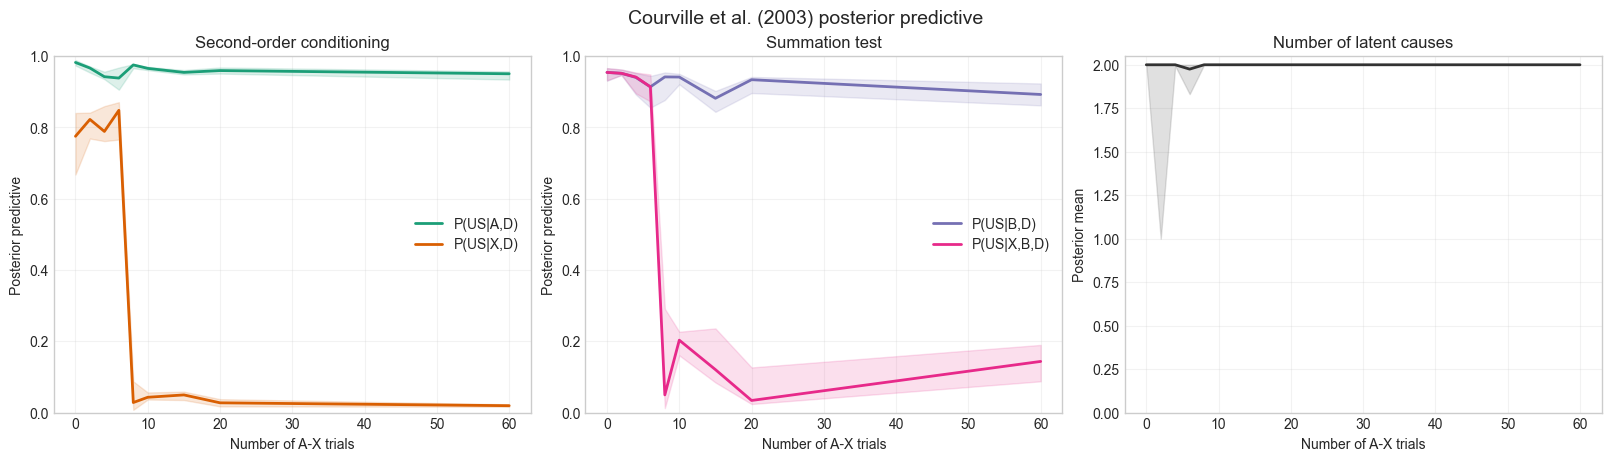

In [5]:
fig, axes = plot_paper_style_results(results)
fig.suptitle("Courville et al. (2003) posterior predictive", fontsize=14)
figure_path = OUTPUT_IMAGE_DIR / "courville_second_order_sweep.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()


## Export representative latent structure

The saved details below focus on the `A-X` point with the strongest median `P(US|X,D)` response and summarize the aligned latent-cause weights and biases across the chains at that point.


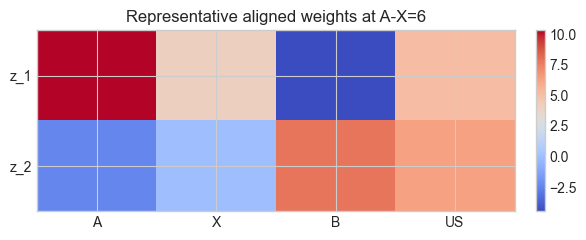

{'curves_csv': 'outputs/latent_data/courville_second_order_curves.csv', 'summary_json': 'outputs/latent_data/courville_second_order_summary.json', 'findings_txt': 'outputs/latent_data/courville_second_order_findings.txt', 'sweep': 'outputs/images/courville_second_order_sweep.png', 'structure': 'outputs/images/courville_representative_structure.png'}


In [6]:
ax_trials = np.asarray(results["ax_trials"], dtype=int)
x_curve = np.asarray(results["aggregated"]["P(US|X,D)"]["center"], dtype=float)
representative_ax = int(ax_trials[np.argmax(x_curve)])
representative_chain_results = [result for result in results["chain_results"] if int(result["ax_trials"]) == representative_ax]
representative_structure = aggregate_chain_structures([result["structure"] for result in representative_chain_results])

curves_csv_path = OUTPUT_DATA_DIR / "courville_second_order_curves.csv"
summary_json_path = OUTPUT_DATA_DIR / "courville_second_order_summary.json"
findings_txt_path = OUTPUT_DATA_DIR / "courville_second_order_findings.txt"
structure_fig_path = OUTPUT_IMAGE_DIR / "courville_representative_structure.png"

curve_rows = []
for idx, ax_value in enumerate(ax_trials):
    curve_rows.append({
        "ax_trials": int(ax_value),
        "P_US_given_A_center": float(results["aggregated"]["P(US|A,D)"]["center"][idx]),
        "P_US_given_X_center": float(results["aggregated"]["P(US|X,D)"]["center"][idx]),
        "P_US_given_B_center": float(results["aggregated"]["P(US|B,D)"]["center"][idx]),
        "P_US_given_XB_center": float(results["aggregated"]["P(US|X,B,D)"]["center"][idx]),
        "mean_num_causes_center": float(results["aggregated"]["mean_num_causes"]["center"][idx]),
    })
with curves_csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(curve_rows[0].keys()))
    writer.writeheader()
    writer.writerows(curve_rows)

weights = np.array(representative_structure["avg_effective_weights"], dtype=float)
fig, ax = plt.subplots(figsize=(6, max(2.5, 0.7 * max(1, weights.shape[0]))))
if weights.size == 0:
    ax.text(0.5, 0.5, "No active latent causes", ha="center", va="center")
    ax.axis("off")
else:
    im = ax.imshow(weights, aspect="auto", cmap="coolwarm")
    ax.set_xticks(range(len(STIMULUS_NAMES)))
    ax.set_xticklabels(STIMULUS_NAMES)
    ax.set_yticks(range(weights.shape[0]))
    ax.set_yticklabels([f"z_{idx + 1}" for idx in range(weights.shape[0])])
    ax.set_title(f"Representative aligned weights at A-X={representative_ax}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(structure_fig_path, dpi=200, bbox_inches="tight")
plt.show()

summary_payload = {
    "settings": {
        "ax_trial_grid": ax_trial_grid.tolist(),
        "chains_per_point": chains_per_point,
        "small_ax_chains": small_ax_chains,
        "iterations": iterations,
        "burn_in": burn_in,
        "thin": thin,
        "base_seed": base_seed,
        "init_causes": init_causes,
        "use_parallel_tempering": use_parallel_tempering,
    },
    "aggregated": results["aggregated"],
    "representative_ax": representative_ax,
    "representative_structure": representative_structure,
    "figure_outputs": {
        "sweep": str(figure_path),
        "structure": str(structure_fig_path),
    },
}
with summary_json_path.open("w") as f:
    json.dump(summary_payload, f, indent=2)

with findings_txt_path.open("w") as f:
    f.write("Courville reimplementation second-order sweep\n")
    f.write(f"Representative A-X point: {representative_ax}\n")
    f.write("\nRepresentative latent structure:\n")
    f.write(f"  active_features: {representative_structure['latent_count']}\n")
    f.write(f"  contributing_chains: {representative_structure['chain_count']}\n")
    f.write(f"  aligned_effective_weights:\n{np.array2string(np.array(representative_structure['avg_effective_weights']), precision=3)}\n")
    f.write(f"  aligned_latent_bias:\n{np.array2string(np.array(representative_structure['avg_latent_bias']), precision=3)}\n")
    f.write(f"  stimulus_bias:\n{np.array2string(np.array(representative_structure['avg_stimulus_bias']), precision=3)}\n")
    f.write("\nSaved figures:\n")
    f.write(f"  sweep: {figure_path}\n")
    f.write(f"  structure: {structure_fig_path}\n")

print({
    "curves_csv": str(curves_csv_path),
    "summary_json": str(summary_json_path),
    "findings_txt": str(findings_txt_path),
    "sweep": str(figure_path),
    "structure": str(structure_fig_path),
})
